[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/MNPS_Likelihood_Evaluator_v1.ipynb)

# MNPS Job Classification Likelihood Evaluator v1.0

## Purpose
This notebook evaluates how likely the Classifier's job classification results would match those of a human evaluator with two years of professional HR experience in job classification.

## Likelihood Score (0-5 Scale)
- **5**: Total and complete match - Classification identical to what a human HR professional would produce
- **4**: Strong match - Minor sub-group difference only, within similar KSAC grouping
- **3**: Acceptable match - Different classification but within similar KSAC grouping, low cost impact
- **2**: Marginal match - Different classification with moderate KSAC dissimilarity, moderate cost impact
- **1**: Poor match - Significantly different classification with high KSAC dissimilarity, high cost impact
- **0**: Complete failure - Completely wrong classification, outside any reasonable similarity grouping

## Evaluation Factors
1. **KSAC Similarity** - How similar are the KSACs between assigned and expected roles?
2. **Salary Cost Impact** - What is the financial cost of any misclassification?
3. **Time to Correct** - How long would it take to correct any errors?
4. **Role Group Alignment** - Is the classification within the correct similarity grouping?

## Human Evaluator Baseline (from HR best practices research)
- Expected accuracy: 85-95% initial accuracy
- Time per classification: 5-9 minutes per job description
- 5-10% correction rate during supervisor review

## Required Input Files
- `Sample JDs.csv` - Original job descriptions being evaluated
- `Job_Classifications_Batch.csv` - Model classification results
- `Evaluation Resources.zip` containing:
  - `MNPS KSACs.csv`
  - `MNPS_Role_Groups_by_KSAC_Similarity_FINAL.csv`
  - `salary_by_major_role_grouping.csv`
  - `Ground Truth Masterfile.csv`
  - `Time to correct an error in hours.csv`

# ==== 1) Setup: Imports, Google Drive Mount, and File Loading ====

In [1]:
import os
import json
import shutil
import datetime as dt
import zipfile
from pathlib import Path
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Create unique run folder with timestamp
timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
run_folder = f"EVAL_{timestamp}"
base_path = Path("/content/drive/My Drive/Likelihood Assessment/Run Results")
run_path = base_path / run_folder
run_path.mkdir(parents=True, exist_ok=True)

# Create outputs subfolder
OUTPUTS_DIR = run_path / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Run folder: {run_path}")
print(f"📁 Outputs dir: {OUTPUTS_DIR}")

# Define root path for uploaded files
RUN_ROOT = Path('/content')

Mounted at /content/drive
📁 Run folder: /content/drive/My Drive/Likelihood Assessment/Run Results/EVAL_20251208_201231
📁 Outputs dir: /content/drive/My Drive/Likelihood Assessment/Run Results/EVAL_20251208_201231/outputs


In [2]:
# ==== File Loading with Robust CSV Handling ====

def load_csv_robust(filepath, description="file"):
    """Load CSV with multiple encoding and delimiter attempts."""
    encodings = ['utf-8', 'latin1', 'iso-8859-1', 'cp1252', 'utf-16']
    delimiters = [',', ';', '\t', '|']

    for encoding in encodings:
        for delimiter in delimiters:
            try:
                df = pd.read_csv(filepath, encoding=encoding, delimiter=delimiter)
                if len(df.columns) > 1:  # Valid parse
                    print(f"✅ Loaded {description}: {len(df)} records (encoding={encoding}, delimiter='{delimiter}')")
                    return df
            except Exception:
                continue

    raise ValueError(f"❌ Could not load {filepath} with any encoding/delimiter combination")

# Unzip Evaluation Resources if present
EVAL_RESOURCES_ZIP = RUN_ROOT / "Evaluation Resources.zip"
if EVAL_RESOURCES_ZIP.exists():
    print(f"📦 Found {EVAL_RESOURCES_ZIP}, extracting...")
    with zipfile.ZipFile(EVAL_RESOURCES_ZIP, 'r') as zip_ref:
        zip_ref.extractall(RUN_ROOT)
    print("✅ Extracted Evaluation Resources")
else:
    print("⚠️  Evaluation Resources.zip not found - make sure to upload it")

# Define file paths
SAMPLE_JDS_CSV = RUN_ROOT / "Sample JDs.csv"
BATCH_RESULTS_CSV = RUN_ROOT / "Job_Classifications_Batch.csv"
MNPS_KSACS_CSV = RUN_ROOT / "MNPS KSACs.csv"
ROLE_GROUPS_CSV = RUN_ROOT / "MNPS_Role_Groups_by_KSAC_Similarity_FINAL.csv"
SALARY_DATA_CSV = RUN_ROOT / "salary_by_major_role_grouping.csv"
GROUND_TRUTH_CSV = RUN_ROOT / "Ground Truth Masterfile.csv"
TIME_TO_CORRECT_CSV = RUN_ROOT / "Time to correct an error in hours.csv"

# Load all files
print("\n" + "="*60)
print("Loading Required Files...")
print("="*60)

# Core input files
if SAMPLE_JDS_CSV.exists():
    sample_jds_df = load_csv_robust(SAMPLE_JDS_CSV, "Sample JDs")
else:
    print(f"⚠️  {SAMPLE_JDS_CSV} not found")
    sample_jds_df = None

if BATCH_RESULTS_CSV.exists():
    batch_results_df = load_csv_robust(BATCH_RESULTS_CSV, "Classification Batch Results")
else:
    print(f"⚠️  {BATCH_RESULTS_CSV} not found")
    batch_results_df = None

# Evaluation resources
if MNPS_KSACS_CSV.exists():
    ksacs_df = load_csv_robust(MNPS_KSACS_CSV, "MNPS KSACs")
else:
    print(f"⚠️  {MNPS_KSACS_CSV} not found")
    ksacs_df = None

if ROLE_GROUPS_CSV.exists():
    role_groups_df = load_csv_robust(ROLE_GROUPS_CSV, "Role Groups by KSAC Similarity")
else:
    print(f"⚠️  {ROLE_GROUPS_CSV} not found")
    role_groups_df = None

if SALARY_DATA_CSV.exists():
    salary_df = load_csv_robust(SALARY_DATA_CSV, "Salary by Major Role Grouping")
else:
    print(f"⚠️  {SALARY_DATA_CSV} not found")
    salary_df = None

if GROUND_TRUTH_CSV.exists():
    ground_truth_df = load_csv_robust(GROUND_TRUTH_CSV, "Ground Truth Masterfile")
else:
    print(f"⚠️  {GROUND_TRUTH_CSV} not found")
    ground_truth_df = None

if TIME_TO_CORRECT_CSV.exists():
    time_to_correct_df = load_csv_robust(TIME_TO_CORRECT_CSV, "Time to Correct Errors")
else:
    print(f"⚠️  {TIME_TO_CORRECT_CSV} not found")
    time_to_correct_df = None

print("\n" + "="*60)
print("File Loading Complete")
print("="*60)

📦 Found /content/Evaluation Resources.zip, extracting...
✅ Extracted Evaluation Resources

Loading Required Files...
✅ Loaded Sample JDs: 61 records (encoding=latin1, delimiter=',')
✅ Loaded Classification Batch Results: 61 records (encoding=utf-8, delimiter=',')
✅ Loaded MNPS KSACs: 315 records (encoding=utf-8, delimiter=',')
✅ Loaded Role Groups by KSAC Similarity: 26 records (encoding=utf-8, delimiter=',')
✅ Loaded Salary by Major Role Grouping: 68 records (encoding=utf-8, delimiter=',')
✅ Loaded Ground Truth Masterfile: 176 records (encoding=latin1, delimiter=',')
✅ Loaded Time to Correct Errors: 1 records (encoding=utf-8, delimiter=',')

File Loading Complete


# ==== 2) Data Exploration and Validation ====

In [3]:
# ==== Explore loaded data structures ====

print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

def show_df_info(df, name):
    """Display dataframe info."""
    if df is not None:
        print(f"\n--- {name} ---")
        print(f"Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        if len(df) > 0:
            print(f"Sample (first 2 rows):")
            display(df.head(2))
    else:
        print(f"\n--- {name} ---")
        print("NOT LOADED")

show_df_info(sample_jds_df, "Sample JDs")
show_df_info(batch_results_df, "Classification Batch Results")
show_df_info(ksacs_df, "MNPS KSACs")
show_df_info(role_groups_df, "Role Groups by KSAC Similarity")
show_df_info(salary_df, "Salary Data")
show_df_info(ground_truth_df, "Ground Truth Masterfile")
show_df_info(time_to_correct_df, "Time to Correct Errors")


DATA EXPLORATION

--- Sample JDs ---
Shape: (61, 8)
Columns: ['Job Code', 'Job Title', 'Position Summary', 'Education', 'Work Experience', 'Essential Functions', 'Licenses and Certifications', 'Knowledge, Skills and Abilities']
Sample (first 2 rows):


,Job Code,Job Title,Position Summary,Education,Work Experience,Essential Functions,Licenses and Certifications,"Knowledge, Skills and Abilities"
0,87894,Teacher Grade 8,The Teacher utilizes current strategies and th...,Bachelor's Degree from an accredited instituti...,Work experience gained through education and ...,Instruct students in an in-person classroom en...,Teaching Certification/License From Tennessee ...,Excellent writing and communication skills\nIn...
1,86690,Mgr Data Quality and Integrity,Supervises staff in ensuring the integrity of ...,Bachelor's Degree in an applicable field Required,Two (2) or more years related experience Requ...,Supervises data quality specialists in data mo...,NaN,Basic Computer Skills



--- Classification Batch Results ---
Shape: (61, 8)
Columns: ['source_row_index', 'job_title_original', 'new_job_title', 'major_role_group', 'minor_sub_group', 'grouping_justification', 'model_used', 'reason_pass5']
Sample (first 2 rows):


,source_row_index,job_title_original,new_job_title,major_role_group,minor_sub_group,grouping_justification,model_used,reason_pass5
0,0,Teacher Grade 8,Teacher,Teacher,NaN,The position's primary responsibilities involv...,gpt-4o-2024-11-20,NaN
1,1,Mgr Data Quality and Integrity,Data Manager II,Manager,II,The position should remain classified as 'Mana...,gpt-4o-2024-11-20,"The role involves supervising staff, evaluatin..."



--- MNPS KSACs ---
Shape: (315, 5)
Columns: ['Role', 'Knowledge', 'Skills', 'Abilities', 'Competencies']
Sample (first 2 rows):


...

,Major Role Grouping,Min Annual Salary,Average Annual Salary,Max Annual Salary
0,Accountant,"$66,944.48","$85,758.38","$90,974.05"
1,Administrative Assistant,"$33,696.00","$58,687.82","$86,872.57"



--- Ground Truth Masterfile ---
Shape: (176, 12)
Columns: ['Job Title', 'Position Summary', 'Education', 'Work Experience', 'Essential Functions', 'Licenses and Certifications', 'Knowledge, Skills and Abilities', 'job_title_original', 'new_job_title', 'major_role_group', 'minor_sub_group', 'grouping_justification']
Sample (first 2 rows):


,Job Title,Position Summary,Education,Work Experience,Essential Functions,Licenses and Certifications,"Knowledge, Skills and Abilities",job_title_original,new_job_title,major_role_group,minor_sub_group,grouping_justification
0,Therapist Audiology,"Support the identification, intervention and e...",Doctoral Degree in Audiology is Required,Experience in social services/health services...,Conduct comprehensive audiologic evaluation of...,School Services Personnel License from the St...,"Thorough knowledge of the principles, practice...",Therapist Audiology,Audiology Therapist I,Therapist,I,"The position summary, essential functions and ..."
1,Therapist Music,The Music Therapist provides music therapy ses...,Master's Degree or additional degrees in music...,1-3 years school system music therapy experien...,Travels daily to assigned schools to deliver m...,Valid certification from the Certification Bo...,Written and oral communication.\nClassroom man...,Therapist Music,Music Therapist I,Therapist,I,"The position summary, essential functions and ..."



--- Time to Correct Errors ---
Shape: (1, 4)
Columns: ['Unnamed: 0', 'Min', 'Average', 'Max']
Sample (first 2 rows):


,Unnamed: 0,Min,Average,Max
0,Time,16,40,80


# ==== 3) Build KSAC Similarity Engine ====

In [4]:
# ==== Build KSAC Similarity Lookup ====

def build_role_to_group_mapping(role_groups_df):
    """Build a mapping from role -> group name."""
    role_to_group = {}

    if role_groups_df is None:
        return role_to_group

    # Try to identify the relevant columns
    group_col = None
    roles_col = None

    for col in role_groups_df.columns:
        col_lower = col.lower()
        if 'group' in col_lower and 'name' in col_lower:
            group_col = col
        elif 'role' in col_lower and ('in' in col_lower or 'list' in col_lower):
            roles_col = col

    # Fallback: use first two columns
    if group_col is None:
        group_col = role_groups_df.columns[0]
    if roles_col is None and len(role_groups_df.columns) > 1:
        roles_col = role_groups_df.columns[1]

    print(f"Using columns: Group='{group_col}', Roles='{roles_col}'")

    for idx, row in role_groups_df.iterrows():
        group_name = str(row[group_col]).strip()
        roles_str = str(row[roles_col]) if roles_col else ''

        # Parse roles (might be comma-separated or semicolon-separated)
        if ',' in roles_str:
            roles = [r.strip() for r in roles_str.split(',')]
        elif ';' in roles_str:
            roles = [r.strip() for r in roles_str.split(';')]
        else:
            roles = [roles_str.strip()]

        for role in roles:
            if role and role.lower() != 'nan':
                role_to_group[role.strip()] = group_name

    return role_to_group

def build_group_to_roles_mapping(role_to_group):
    """Build inverse mapping: group -> [roles]."""
    group_to_roles = {}
    for role, group in role_to_group.items():
        if group not in group_to_roles:
            group_to_roles[group] = []
        group_to_roles[group].append(role)
    return group_to_roles

# Build mappings
print("Building KSAC Similarity Mappings...")
role_to_group = build_role_to_group_mapping(role_groups_df)
group_to_roles = build_group_to_roles_mapping(role_to_group)

print(f"\n✅ Mapped {len(role_to_group)} roles to {len(group_to_roles)} groups")
print("\nGroups and their roles:")
for group, roles in group_to_roles.items():
    print(f"  {group}: {roles}")

Building KSAC Similarity Mappings...
Using columns: Group='Group Name', Roles='Roles in Group'

✅ Mapped 63 roles to 26 groups

Groups and their roles:
  District Executive Leadership: ['Chief', 'Deputy Chief', 'Executive Director', 'Executive Officer', 'Director']
  School Site Leadership: ['Principal', 'Assistant Principal', 'Dean']
  Administrative Support: ['Administrative Assistant', 'Assistant', 'Secretary', 'Receptionist', 'Clerk']
  Financial Operations, Planning and Procurement: ['Accountant', 'Auditor', 'Budget Partner', 'Buyer', 'Agent']
  Site Financial Operations: ['Cashier']
  Specialized Student Services: ['Counselor', 'Psychologist', 'Social Worker', 'Therapist', 'Pathologist (Speech-Language Focused)']
  Direct Instructional Staff: ['Teacher', 'Instructor', 'Tutor']
  Instructional Support & Development: ['Coach', 'Facilitator', 'Trainer']
  Direct Student Support: ['Aide', 'Monitor', 'Paraprofessional', 'Associate']
  Technology Architecture & Development: ['Architect

In [5]:
# ==== KSAC Similarity Calculation Functions ====

def get_ksac_profile(role, ksacs_df):
    """Get KSAC profile for a role."""
    if ksacs_df is None:
        return None

    # Find the role column
    role_col = None
    for col in ksacs_df.columns:
        if 'role' in col.lower():
            role_col = col
            break

    if role_col is None:
        role_col = ksacs_df.columns[0]

    # Find matching role (case-insensitive)
    role_lower = role.lower().strip()
    matching = ksacs_df[ksacs_df[role_col].str.lower().str.strip() == role_lower]

    if len(matching) > 0:
        return matching.iloc[0]

    return None

def calculate_ksac_similarity(role1, role2, ksacs_df, role_to_group):
    """
    Calculate KSAC-based similarity between two roles.
    Returns similarity score (0-1, where 1 = identical).
    """
    # Normalize role names
    role1 = str(role1).strip()
    role2 = str(role2).strip()

    # Exact match
    if role1.lower() == role2.lower():
        return 1.0

    # Check if in same KSAC group
    group1 = role_to_group.get(role1, role_to_group.get(role1.title(), None))
    group2 = role_to_group.get(role2, role_to_group.get(role2.title(), None))

    if group1 and group2:
        if group1 == group2:
            # Same group - high similarity
            return 0.75
        else:
            # Different groups - moderate to low similarity
            # Could enhance with actual KSAC profile comparison
            return 0.3

    # One or both roles not in mapping - use text-based similarity
    # Simple approach: check for common words
    words1 = set(role1.lower().split())
    words2 = set(role2.lower().split())

    if words1 & words2:  # Some common words
        return 0.4

    return 0.1  # Very different

def is_within_similarity_group(role1, role2, role_to_group):
    """Check if two roles are within the same KSAC similarity group."""
    role1 = str(role1).strip()
    role2 = str(role2).strip()

    group1 = role_to_group.get(role1, role_to_group.get(role1.title(), None))
    group2 = role_to_group.get(role2, role_to_group.get(role2.title(), None))

    if group1 and group2:
        return group1 == group2

    return False

print("✅ KSAC Similarity functions defined")

✅ KSAC Similarity functions defined


# ==== 4) Build Salary Cost Engine ====

In [14]:
# ==== Build Salary Cost Lookup ====

def clean_salary_value(value):
    """
    Cleans a salary string by removing currency symbols and commas, then converts to float.
    Returns 0.0 if conversion fails.
    """
    if isinstance(value, (int, float)):
        return float(value)
    try:
        # Remove '$', ',', and whitespace, then convert to float
        cleaned_value = str(value).replace('$', '').replace(',', '').strip()
        return float(cleaned_value)
    except (ValueError, TypeError):
        return 0.0 # Default to 0.0 if cleaning/conversion fails

def build_salary_lookup(salary_df):
    """
    Build salary lookup by role.
    """
    salary_lookup = {}

    if salary_df is None:
        return salary_lookup

    print(f"Salary DataFrame columns: {list(salary_df.columns)}")

    # Try to identify columns
    role_col = None
    min_col = None
    max_col = None
    avg_col = None

    for col in salary_df.columns:
        col_lower = col.lower()
        if 'role' in col_lower or 'group' in col_lower or 'major' in col_lower:
            role_col = col
        elif 'min' in col_lower:
            min_col = col
        elif 'max' in col_lower:
            max_col = col
        elif 'avg' in col_lower or 'average' in col_lower or 'mean' in col_lower:
            avg_col = col

    # Fallbacks
    if role_col is None:
        role_col = salary_df.columns[0]

    print(f"Using role column: {role_col}")

    for idx, row in salary_df.iterrows():
        role_name = str(row[role_col]).strip()

        salary_info = {
            'min': clean_salary_value(row[min_col]) if min_col else None,
            'max': clean_salary_value(row[max_col]) if max_col else None,
            'avg': clean_salary_value(row[avg_col]) if avg_col else None
        }

        # Calculate avg if not present
        if salary_info['avg'] is None and salary_info['min'] is not None and salary_info['max'] is not None:
            try:
                salary_info['avg'] = (salary_info['min'] + salary_info['max']) / 2
            except:
                pass

        salary_lookup[role_name] = salary_info
        salary_lookup[role_name.lower()] = salary_info

    return salary_lookup

salary_lookup = build_salary_lookup(salary_df)
print(f"\n✅ Built salary lookup for {len(salary_lookup)//2} roles")

# Display sample
print("\nSample salary data:")
for i, (role, info) in enumerate(list(salary_lookup.items())[:5]):
    if role == role.title():  # Show only title-cased versions
        print(f"  {role}: min=${info.get('min', 'N/A'):,.2f}, avg=${info.get('avg', 'N/A'):,.2f}, max=${info.get('max', 'N/A'):,.2f}")

Salary DataFrame columns: ['Major Role Grouping', ' Min Annual Salary ', ' Average Annual Salary ', ' Max Annual Salary ']
Using role column: Major Role Grouping

✅ Built salary lookup for 68 roles

Sample salary data:
  Accountant: min=$66,944.48, avg=$85,758.38, max=$90,974.05
  Administrative Assistant: min=$33,696.00, avg=$58,687.82, max=$86,872.57
  Advisor: min=$56,381.06, avg=$71,606.71, max=$93,470.17


In [7]:
# ==== Salary Cost Calculation Functions ====

def get_role_salary(role, salary_lookup):
    """Get salary info for a role."""
    role = str(role).strip()

    # Try exact match, then lowercase, then title case
    if role in salary_lookup:
        return salary_lookup[role]
    if role.lower() in salary_lookup:
        return salary_lookup[role.lower()]
    if role.title() in salary_lookup:
        return salary_lookup[role.title()]

    return None

def calculate_salary_cost_impact(assigned_role, expected_role, salary_lookup):
    """
    Calculate the financial cost impact of a misclassification.
    Returns (absolute_difference, percentage_difference, severity_level).
    """
    assigned_salary = get_role_salary(assigned_role, salary_lookup)
    expected_salary = get_role_salary(expected_role, salary_lookup)

    # Default values if salary not found
    default_avg = 50000

    assigned_avg = float(assigned_salary.get('avg', default_avg)) if assigned_salary else default_avg
    expected_avg = float(expected_salary.get('avg', default_avg)) if expected_salary else default_avg

    # Handle NaN
    if pd.isna(assigned_avg):
        assigned_avg = default_avg
    if pd.isna(expected_avg):
        expected_avg = default_avg

    # Calculate differences
    abs_diff = abs(assigned_avg - expected_avg)
    pct_diff = abs_diff / expected_avg * 100 if expected_avg > 0 else 0

    # Determine severity level
    if pct_diff < 5:
        severity = 'LOW'
    elif pct_diff < 15:
        severity = 'MODERATE'
    elif pct_diff < 30:
        severity = 'HIGH'
    else:
        severity = 'SEVERE'

    return {
        'absolute_diff': abs_diff,
        'percentage_diff': pct_diff,
        'severity': severity,
        'assigned_salary': assigned_avg,
        'expected_salary': expected_avg
    }

print("✅ Salary cost calculation functions defined")

✅ Salary cost calculation functions defined


# ==== 5) Build Time to Correct Engine ====

In [8]:
# ==== Build Time to Correct Lookup ====

def build_time_to_correct_lookup(time_df):
    """Build time to correct lookup."""
    time_lookup = {}

    if time_df is None:
        # Use default values based on error severity
        return {
            'default': {
                'EXACT_MATCH': 0,
                'MINOR_SUB_GROUP_DIFF': 0.5,
                'SAME_GROUP_DIFF_ROLE': 1.0,
                'DIFFERENT_GROUP': 2.0,
                'COMPLETELY_WRONG': 4.0
            }
        }

    print(f"Time to Correct DataFrame columns: {list(time_df.columns)}")

    # Parse the time to correct data
    for idx, row in time_df.iterrows():
        for col in time_df.columns:
            val = row[col]
            if pd.notna(val):
                try:
                    time_lookup[str(col).strip()] = float(val)
                except:
                    time_lookup[str(col).strip()] = str(val)

    return time_lookup

time_to_correct_lookup = build_time_to_correct_lookup(time_to_correct_df)
print(f"\n✅ Built time to correct lookup")
print(f"Time data: {time_to_correct_lookup}")

Time to Correct DataFrame columns: ['Unnamed: 0', 'Min', 'Average', 'Max']

✅ Built time to correct lookup
Time data: {'Unnamed: 0': 'Time', 'Min': 16.0, 'Average': 40.0, 'Max': 80.0}


In [9]:
# ==== Time to Correct Calculation Functions ====

def estimate_time_to_correct(assigned_role, expected_role, ksac_similarity, role_to_group, time_lookup):
    """
    Estimate time to correct a misclassification in hours.
    """
    assigned_role = str(assigned_role).strip()
    expected_role = str(expected_role).strip()

    # Exact match - no correction needed
    if assigned_role.lower() == expected_role.lower():
        return 0.0, 'EXACT_MATCH'

    # Check if in same group
    same_group = is_within_similarity_group(assigned_role, expected_role, role_to_group)

    # Determine error type based on KSAC similarity and group membership
    if ksac_similarity >= 0.9:
        error_type = 'MINOR_SUB_GROUP_DIFF'
        base_time = 0.5
    elif same_group:
        error_type = 'SAME_GROUP_DIFF_ROLE'
        base_time = 1.0
    elif ksac_similarity >= 0.4:
        error_type = 'DIFFERENT_GROUP'
        base_time = 2.0
    else:
        error_type = 'COMPLETELY_WRONG'
        base_time = 4.0

    # Look up specific time if available
    if isinstance(time_lookup, dict):
        if 'default' in time_lookup and error_type in time_lookup['default']:
            base_time = time_lookup['default'][error_type]
        elif error_type in time_lookup:
            try:
                base_time = float(time_lookup[error_type])
            except:
                pass

    return base_time, error_type

print("✅ Time to correct calculation functions defined")

✅ Time to correct calculation functions defined


# ==== 6) Core Likelihood Score Calculation ====

In [10]:
# ==== LIKELIHOOD SCORE CALCULATION ====
# Scale: 0 = Complete failure, 5 = Perfect match

# Human evaluator baseline from HR best practices research
HUMAN_EVALUATOR_BASELINE = {
    'accuracy_range': (0.85, 0.95),  # 85-95% initial accuracy
    'time_per_jd_minutes': (5, 9),   # 5-9 minutes per job description
    'correction_rate': (0.05, 0.10)  # 5-10% correction rate
}

def calculate_likelihood_score(
    assigned_major_role,
    expected_major_role,
    assigned_minor_sub,
    expected_minor_sub,
    role_to_group,
    salary_lookup,
    time_lookup,
    ksacs_df=None
):
    """
    Calculate the Likelihood Score (0-5) for a single classification.

    This score represents how likely the classifier's result would match
    that of a human evaluator with 2 years of professional HR experience.

    Returns:
        dict with likelihood_score and supporting details
    """
    # Normalize inputs
    assigned_major = str(assigned_major_role).strip() if pd.notna(assigned_major_role) else ''
    expected_major = str(expected_major_role).strip() if pd.notna(expected_major_role) else ''
    assigned_minor = str(assigned_minor_sub).strip() if pd.notna(assigned_minor_sub) else ''
    expected_minor = str(expected_minor_sub).strip() if pd.notna(expected_minor_sub) else ''

    # Initialize result
    result = {
        'assigned_major': assigned_major,
        'expected_major': expected_major,
        'assigned_minor': assigned_minor,
        'expected_minor': expected_minor,
        'major_match': False,
        'minor_match': False,
        'full_match': False,
        'ksac_similarity': 0.0,
        'same_ksac_group': False,
        'salary_cost_impact': {},
        'time_to_correct_hours': 0.0,
        'error_type': 'UNKNOWN',
        'likelihood_score': 0.0,
        'score_components': {},
        'interpretation': ''
    }

    # Handle empty/unclassifiable
    if not assigned_major or not expected_major:
        result['likelihood_score'] = 0.0
        result['interpretation'] = 'Unable to evaluate - missing classification data'
        return result

    # 1. Check Major Role Match
    result['major_match'] = assigned_major.lower() == expected_major.lower()

    # 2. Check Minor Sub-group Match
    result['minor_match'] = assigned_minor.lower() == expected_minor.lower()

    # 3. Full Match
    result['full_match'] = result['major_match'] and result['minor_match']

    # 4. Calculate KSAC Similarity
    result['ksac_similarity'] = calculate_ksac_similarity(
        assigned_major, expected_major, ksacs_df, role_to_group
    )

    # 5. Check if in Same KSAC Group
    result['same_ksac_group'] = is_within_similarity_group(
        assigned_major, expected_major, role_to_group
    )

    # 6. Calculate Salary Cost Impact
    result['salary_cost_impact'] = calculate_salary_cost_impact(
        assigned_major, expected_major, salary_lookup
    )

    # 7. Estimate Time to Correct
    time_hours, error_type = estimate_time_to_correct(
        assigned_major, expected_major, result['ksac_similarity'],
        role_to_group, time_lookup
    )
    result['time_to_correct_hours'] = time_hours
    result['error_type'] = error_type

    # ==== CALCULATE LIKELIHOOD SCORE ====
    # Base the score on multiple weighted factors

    # Component scores (each 0-1 scale)

    # Major Role Match Component (40% weight)
    if result['major_match']:
        major_component = 1.0
    elif result['same_ksac_group']:
        major_component = 0.6  # Same group, different role
    elif result['ksac_similarity'] >= 0.5:
        major_component = 0.3  # Somewhat similar
    else:
        major_component = 0.0  # Very different

    # Minor Sub-group Match Component (15% weight)
    if result['minor_match']:
        minor_component = 1.0
    elif result['major_match']:  # Major matches but minor doesn't
        minor_component = 0.5
    else:
        minor_component = 0.0

    # KSAC Similarity Component (25% weight)
    ksac_component = result['ksac_similarity']

    # Cost Impact Component (10% weight) - inverse: lower cost = higher score
    salary_severity = result['salary_cost_impact'].get('severity', 'MODERATE')
    cost_component_map = {'LOW': 1.0, 'MODERATE': 0.7, 'HIGH': 0.3, 'SEVERE': 0.0}
    cost_component = cost_component_map.get(salary_severity, 0.5)

    # Time to Correct Component (10% weight) - inverse: less time = higher score
    time_component = max(0, 1.0 - (result['time_to_correct_hours'] / 4.0))  # Normalize to 4 hours max

    # Store components
    result['score_components'] = {
        'major_match_component': major_component,
        'minor_match_component': minor_component,
        'ksac_similarity_component': ksac_component,
        'cost_impact_component': cost_component,
        'time_to_correct_component': time_component
    }

    # Calculate weighted score (0-1 scale)
    weights = {
        'major_match': 0.40,
        'minor_match': 0.15,
        'ksac_similarity': 0.25,
        'cost_impact': 0.10,
        'time_to_correct': 0.10
    }

    weighted_score = (
        weights['major_match'] * major_component +
        weights['minor_match'] * minor_component +
        weights['ksac_similarity'] * ksac_component +
        weights['cost_impact'] * cost_component +
        weights['time_to_correct'] * time_component
    )

    # Convert to 0-5 scale
    likelihood_score = weighted_score * 5.0
    result['likelihood_score'] = round(likelihood_score, 2)

    # Generate interpretation
    if result['likelihood_score'] >= 4.5:
        result['interpretation'] = 'EXCELLENT: Near-perfect match to human evaluator'
    elif result['likelihood_score'] >= 4.0:
        result['interpretation'] = 'VERY GOOD: Strong alignment with human evaluator'
    elif result['likelihood_score'] >= 3.0:
        result['interpretation'] = 'ACCEPTABLE: Reasonable match, within similar KSAC grouping'
    elif result['likelihood_score'] >= 2.0:
        result['interpretation'] = 'MARGINAL: Different classification, moderate impact'
    elif result['likelihood_score'] >= 1.0:
        result['interpretation'] = 'POOR: Significant misclassification, high impact'
    else:
        result['interpretation'] = 'FAILURE: Complete misclassification'

    return result

print("✅ Likelihood Score calculation function defined")
print(f"\nHuman Evaluator Baseline:")
print(f"  - Expected Accuracy: {HUMAN_EVALUATOR_BASELINE['accuracy_range'][0]*100:.0f}% - {HUMAN_EVALUATOR_BASELINE['accuracy_range'][1]*100:.0f}%")
print(f"  - Time per JD: {HUMAN_EVALUATOR_BASELINE['time_per_jd_minutes'][0]} - {HUMAN_EVALUATOR_BASELINE['time_per_jd_minutes'][1]} minutes")
print(f"  - Correction Rate: {HUMAN_EVALUATOR_BASELINE['correction_rate'][0]*100:.0f}% - {HUMAN_EVALUATOR_BASELINE['correction_rate'][1]*100:.0f}%")

✅ Likelihood Score calculation function defined

Human Evaluator Baseline:
  - Expected Accuracy: 85% - 95%
  - Time per JD: 5 - 9 minutes
  - Correction Rate: 5% - 10%


# ==== 7) Evaluate Batch Results ====

In [15]:
# ==== BATCH EVALUATION ====

def identify_columns(df, col_type):
    """
    Intelligently identify column names for different data types.
    """
    columns = df.columns.tolist()

    patterns = {
        'assigned_major': ['major_role_group', 'major_role', 'assigned_major', 'predicted_role', 'pred_major'],
        'expected_major': ['expected_major', 'expected_role', 'true_major', 'ground_truth_major', 'Expected Role Group', 'expected_major_role_group'],
        'assigned_minor': ['minor_sub_group', 'minor_role', 'assigned_minor', 'pred_minor'],
        'expected_minor': ['expected_minor', 'expected_sub', 'true_minor', 'ground_truth_minor', 'Expected Sub Group', 'expected_minor_sub_group'],
        'job_title': ['job_title', 'job_title_original', 'title', 'Job Title'],
        'row_index': ['source_row_index', 'row_index', 'index', 'id']
    }

    for pattern in patterns.get(col_type, []):
        for col in columns:
            if pattern.lower() in col.lower():
                return col

    return None

def evaluate_batch_results(batch_df, role_to_group, salary_lookup, time_lookup, ksacs_df=None):
    """
    Evaluate an entire batch of classification results.
    """
    print("\n" + "="*80)
    print("BATCH EVALUATION")
    print("="*80)

    # Identify columns
    assigned_major_col = identify_columns(batch_df, 'assigned_major')
    expected_major_col = identify_columns(batch_df, 'expected_major')
    assigned_minor_col = identify_columns(batch_df, 'assigned_minor')
    expected_minor_col = identify_columns(batch_df, 'expected_minor')
    job_title_col = identify_columns(batch_df, 'job_title')
    row_index_col = identify_columns(batch_df, 'row_index')

    print(f"\nIdentified columns:")
    print(f"  Assigned Major: {assigned_major_col}")
    print(f"  Expected Major: {expected_major_col}")
    print(f"  Assigned Minor: {assigned_minor_col}")
    print(f"  Expected Minor: {expected_minor_col}")
    print(f"  Job Title: {job_title_col}")
    print(f"  Row Index: {row_index_col}")

    # Validate required columns
    if assigned_major_col is None or expected_major_col is None:
        print("\n❌ ERROR: Could not identify required columns for major role comparison")
        print(f"   Available columns: {list(batch_df.columns)}")
        return None

    # Evaluate each record
    results = []

    print(f"\nEvaluating {len(batch_df)} records...")

    for idx, row in batch_df.iterrows():
        assigned_major = row.get(assigned_major_col, '')
        expected_major = row.get(expected_major_col, '')
        assigned_minor = row.get(assigned_minor_col, '') if assigned_minor_col else ''
        expected_minor = row.get(expected_minor_col, '') if expected_minor_col else ''
        job_title = row.get(job_title_col, f'Row {idx}') if job_title_col else f'Row {idx}'
        row_idx = row.get(row_index_col, idx) if row_index_col else idx

        # Calculate likelihood score
        eval_result = calculate_likelihood_score(
            assigned_major, expected_major,
            assigned_minor, expected_minor,
            role_to_group, salary_lookup, time_lookup, ksacs_df
        )

        # Add identifiers
        eval_result['source_row_index'] = row_idx
        eval_result['job_title_original'] = job_title

        results.append(eval_result)

    return results

# Run evaluation if batch results are loaded
if batch_results_df is not None and ground_truth_df is not None:
    # Prepare ground truth for merging
    ground_truth_renamed_df = ground_truth_df[['job_title_original', 'major_role_group', 'minor_sub_group']].copy()
    ground_truth_renamed_df.rename(columns={
        'major_role_group': 'expected_major_role_group',
        'minor_sub_group': 'expected_minor_sub_group'
    }, inplace=True)

    # Merge batch results with ground truth
    # Use 'job_title_original' for merging. A left merge is appropriate to keep all batch results and add ground truth where available.
    merged_df = pd.merge(batch_results_df, ground_truth_renamed_df, on='job_title_original', how='left', suffixes=('_assigned', '_groundtruth'))

    evaluation_results = evaluate_batch_results(
        merged_df, role_to_group, salary_lookup,
        time_to_correct_lookup, ksacs_df
    )

    if evaluation_results:
        results_df = pd.DataFrame(evaluation_results)
        print(f"\n✅ Evaluated {len(results_df)} records")
else:
    print("\n⚠️ Not all required dataframes (batch_results_df, ground_truth_df) are available for evaluation.")
    evaluation_results = None
    results_df = None


BATCH EVALUATION

Identified columns:
  Assigned Major: major_role_group
  Expected Major: expected_major_role_group
  Assigned Minor: minor_sub_group
  Expected Minor: expected_minor_sub_group
  Job Title: job_title_original
  Row Index: source_row_index

Evaluating 61 records...

✅ Evaluated 61 records


# ==== 8) Generate Summary Statistics ====

In [16]:
# ==== SUMMARY STATISTICS ====

def generate_summary_statistics(results_df):
    """
    Generate comprehensive summary statistics from evaluation results.
    """
    if results_df is None or len(results_df) == 0:
        print("No results to summarize")
        return None

    total_records = len(results_df)

    summary = {
        'total_records': total_records,

        # Likelihood Score Statistics
        'likelihood_score_mean': results_df['likelihood_score'].mean(),
        'likelihood_score_median': results_df['likelihood_score'].median(),
        'likelihood_score_std': results_df['likelihood_score'].std(),
        'likelihood_score_min': results_df['likelihood_score'].min(),
        'likelihood_score_max': results_df['likelihood_score'].max(),

        # Match Statistics
        'major_match_count': results_df['major_match'].sum(),
        'major_match_rate': results_df['major_match'].mean() * 100,
        'minor_match_count': results_df['minor_match'].sum(),
        'minor_match_rate': results_df['minor_match'].mean() * 100,
        'full_match_count': results_df['full_match'].sum(),
        'full_match_rate': results_df['full_match'].mean() * 100,

        # KSAC Similarity Statistics
        'ksac_similarity_mean': results_df['ksac_similarity'].mean(),
        'same_ksac_group_count': results_df['same_ksac_group'].sum(),
        'same_ksac_group_rate': results_df['same_ksac_group'].mean() * 100,

        # Time to Correct Statistics
        'total_correction_hours': results_df['time_to_correct_hours'].sum(),
        'avg_correction_hours': results_df['time_to_correct_hours'].mean(),

        # Score Distribution
        'score_5_count': len(results_df[results_df['likelihood_score'] >= 4.5]),
        'score_4_count': len(results_df[(results_df['likelihood_score'] >= 3.5) & (results_df['likelihood_score'] < 4.5)]),
        'score_3_count': len(results_df[(results_df['likelihood_score'] >= 2.5) & (results_df['likelihood_score'] < 3.5)]),
        'score_2_count': len(results_df[(results_df['likelihood_score'] >= 1.5) & (results_df['likelihood_score'] < 2.5)]),
        'score_1_count': len(results_df[(results_df['likelihood_score'] >= 0.5) & (results_df['likelihood_score'] < 1.5)]),
        'score_0_count': len(results_df[results_df['likelihood_score'] < 0.5]),
    }

    # Compare to Human Evaluator Baseline
    human_accuracy_low, human_accuracy_high = HUMAN_EVALUATOR_BASELINE['accuracy_range']
    classifier_accuracy = summary['major_match_rate'] / 100

    if classifier_accuracy >= human_accuracy_high:
        summary['vs_human_assessment'] = 'EXCEEDS human evaluator performance'
    elif classifier_accuracy >= human_accuracy_low:
        summary['vs_human_assessment'] = 'MEETS human evaluator performance'
    elif classifier_accuracy >= human_accuracy_low - 0.10:
        summary['vs_human_assessment'] = 'APPROACHES human evaluator performance'
    else:
        summary['vs_human_assessment'] = 'BELOW human evaluator performance'

    return summary

# Generate summary if results exist
if results_df is not None:
    summary = generate_summary_statistics(results_df)

    print("\n" + "="*80)
    print("EVALUATION SUMMARY")
    print("="*80)

    print(f"\n📊 LIKELIHOOD SCORE STATISTICS:")
    print(f"   Mean Score: {summary['likelihood_score_mean']:.2f} / 5.00")
    print(f"   Median Score: {summary['likelihood_score_median']:.2f} / 5.00")
    print(f"   Std Dev: {summary['likelihood_score_std']:.2f}")
    print(f"   Range: {summary['likelihood_score_min']:.2f} - {summary['likelihood_score_max']:.2f}")

    print(f"\n📈 MATCH RATES:")
    print(f"   Major Role Match: {summary['major_match_count']}/{summary['total_records']} ({summary['major_match_rate']:.1f}%)")
    print(f"   Minor Sub-group Match: {summary['minor_match_count']}/{summary['total_records']} ({summary['minor_match_rate']:.1f}%)")
    print(f"   Full Match (Major + Minor): {summary['full_match_count']}/{summary['total_records']} ({summary['full_match_rate']:.1f}%)")

    print(f"\n🔗 KSAC ALIGNMENT:")
    print(f"   Average KSAC Similarity: {summary['ksac_similarity_mean']:.2f}")
    print(f"   Same KSAC Group: {summary['same_ksac_group_count']}/{summary['total_records']} ({summary['same_ksac_group_rate']:.1f}%)")

    print(f"\n⏱️ TIME TO CORRECT ESTIMATES:")
    print(f"   Total Hours to Correct All Errors: {summary['total_correction_hours']:.1f} hours")
    print(f"   Average Hours per Record: {summary['avg_correction_hours']:.2f} hours")

    print(f"\n📊 SCORE DISTRIBUTION:")
    print(f"   Score 5 (Excellent): {summary['score_5_count']} ({summary['score_5_count']/summary['total_records']*100:.1f}%)")
    print(f"   Score 4 (Very Good): {summary['score_4_count']} ({summary['score_4_count']/summary['total_records']*100:.1f}%)")
    print(f"   Score 3 (Acceptable): {summary['score_3_count']} ({summary['score_3_count']/summary['total_records']*100:.1f}%)")
    print(f"   Score 2 (Marginal): {summary['score_2_count']} ({summary['score_2_count']/summary['total_records']*100:.1f}%)")
    print(f"   Score 1 (Poor): {summary['score_1_count']} ({summary['score_1_count']/summary['total_records']*100:.1f}%)")
    print(f"   Score 0 (Failure): {summary['score_0_count']} ({summary['score_0_count']/summary['total_records']*100:.1f}%)")

    print(f"\n🎯 COMPARISON TO HUMAN EVALUATOR:")
    print(f"   Human Baseline Accuracy: {HUMAN_EVALUATOR_BASELINE['accuracy_range'][0]*100:.0f}% - {HUMAN_EVALUATOR_BASELINE['accuracy_range'][1]*100:.0f}%")
    print(f"   Classifier Accuracy: {summary['major_match_rate']:.1f}%")
    print(f"   Assessment: {summary['vs_human_assessment']}")
else:
    summary = None
    print("No results to summarize")


EVALUATION SUMMARY

📊 LIKELIHOOD SCORE STATISTICS:
   Mean Score: 0.33 / 5.00
   Median Score: 0.00 / 5.00
   Std Dev: 1.11
   Range: 0.00 - 5.00

📈 MATCH RATES:
   Major Role Match: 3/61 (4.9%)
   Minor Sub-group Match: 3/61 (4.9%)
   Full Match (Major + Minor): 1/61 (1.6%)

🔗 KSAC ALIGNMENT:
   Average KSAC Similarity: 0.08
   Same KSAC Group: 4/61 (6.6%)

⏱️ TIME TO CORRECT ESTIMATES:
   Total Hours to Correct All Errors: 17.0 hours
   Average Hours per Record: 0.28 hours

📊 SCORE DISTRIBUTION:
   Score 5 (Excellent): 3 (4.9%)
   Score 4 (Very Good): 0 (0.0%)
   Score 3 (Acceptable): 1 (1.6%)
   Score 2 (Marginal): 0 (0.0%)
   Score 1 (Poor): 1 (1.6%)
   Score 0 (Failure): 56 (91.8%)

🎯 COMPARISON TO HUMAN EVALUATOR:
   Human Baseline Accuracy: 85% - 95%
   Classifier Accuracy: 4.9%
   Assessment: BELOW human evaluator performance


# ==== 9) Detailed Record Analysis ====

In [17]:
# ==== DETAILED RECORD ANALYSIS ====

if results_df is not None:
    print("\n" + "="*80)
    print("DETAILED RECORD ANALYSIS")
    print("="*80)

    # Show records by score category
    print("\n📋 RECORDS BY LIKELIHOOD SCORE CATEGORY:")

    # Excellent matches (Score >= 4.5)
    excellent = results_df[results_df['likelihood_score'] >= 4.5]
    print(f"\n✅ EXCELLENT (Score >= 4.5): {len(excellent)} records")
    if len(excellent) > 0:
        display(excellent[['job_title_original', 'assigned_major', 'expected_major', 'likelihood_score', 'interpretation']].head(5))

    # Problem classifications (Score < 2.5)
    problems = results_df[results_df['likelihood_score'] < 2.5]
    print(f"\n⚠️ PROBLEM CLASSIFICATIONS (Score < 2.5): {len(problems)} records")
    if len(problems) > 0:
        display(problems[['job_title_original', 'assigned_major', 'expected_major', 'likelihood_score', 'interpretation', 'time_to_correct_hours']].head(10))

    # Mismatches within same KSAC group (potentially acceptable)
    same_group_mismatches = results_df[(~results_df['major_match']) & (results_df['same_ksac_group'])]
    print(f"\n🔄 MISMATCHES WITHIN SAME KSAC GROUP: {len(same_group_mismatches)} records")
    if len(same_group_mismatches) > 0:
        display(same_group_mismatches[['job_title_original', 'assigned_major', 'expected_major', 'ksac_similarity', 'likelihood_score']].head(5))

    # Mismatches outside KSAC group (more severe)
    diff_group_mismatches = results_df[(~results_df['major_match']) & (~results_df['same_ksac_group'])]
    print(f"\n❌ MISMATCHES OUTSIDE KSAC GROUP (Severe): {len(diff_group_mismatches)} records")
    if len(diff_group_mismatches) > 0:
        display(diff_group_mismatches[['job_title_original', 'assigned_major', 'expected_major', 'ksac_similarity', 'likelihood_score', 'time_to_correct_hours']].head(10))
else:
    print("No results to analyze")


DETAILED RECORD ANALYSIS

📋 RECORDS BY LIKELIHOOD SCORE CATEGORY:

✅ EXCELLENT (Score >= 4.5): 3 records


,job_title_original,assigned_major,expected_major,likelihood_score,interpretation
17,Designer STEM Instructional Lead,Designer,Designer,4.62,EXCELLENT: Near-perfect match to human evaluator
21,Driver Truck,Driver,Driver,5.00,EXCELLENT: Near-perfect match to human evaluator
58,Dispatcher Bus,Dispatcher,Dispatcher,4.62,EXCELLENT: Near-perfect match to human evaluator



⚠️ PROBLEM CLASSIFICATIONS (Score < 2.5): 57 records


,job_title_original,assigned_major,expected_major,likelihood_score,interpretation,time_to_correct_hours
0,Teacher Grade 8,Teacher,,0.0,Unable to evaluate - missing classification data,0.0
1,Mgr Data Quality and Integrity,Manager,,0.0,Unable to evaluate - missing classification data,0.0
2,Coord Evaluation RAE,Analyst,,0.0,Unable to evaluate - missing classification data,0.0
3,Dir Assessment RAE,Director,,0.0,Unable to evaluate - missing classification data,0.0
4,Analyst Data Operations RAE,Analyst,,0.0,Unable to evaluate - missing classification data,0.0
5,Coord Arts Visual and Performing,Coordinator,,0.0,Unable to evaluate - missing classification data,0.0
6,Teacher Social Studies Sociology,Teacher,,0.0,Unable to evaluate - missing classification data,0.0
7,Spec School Based Trauma Informed,Coach,,0.0,Unable to evaluate - missing classification data,0.0
8,Tech Instructional Design Lead,Coach,,0.0,Unable to evaluate - missing classification data,0.0
9,Coach College & Career Readiness and Success,Coordinator,,0.0,Unable to evaluate - missing classification data,0.0



🔄 MISMATCHES WITHIN SAME KSAC GROUP: 1 records


,job_title_original,assigned_major,expected_major,ksac_similarity,likelihood_score
33,Clerk Front Desk Bilingual,Administrative Assistant,Clerk,0.75,3.26



❌ MISMATCHES OUTSIDE KSAC GROUP (Severe): 57 records


,job_title_original,assigned_major,expected_major,ksac_similarity,likelihood_score,time_to_correct_hours
0,Teacher Grade 8,Teacher,,0.0,0.0,0.0
1,Mgr Data Quality and Integrity,Manager,,0.0,0.0,0.0
2,Coord Evaluation RAE,Analyst,,0.0,0.0,0.0
3,Dir Assessment RAE,Director,,0.0,0.0,0.0
4,Analyst Data Operations RAE,Analyst,,0.0,0.0,0.0
5,Coord Arts Visual and Performing,Coordinator,,0.0,0.0,0.0
6,Teacher Social Studies Sociology,Teacher,,0.0,0.0,0.0
7,Spec School Based Trauma Informed,Coach,,0.0,0.0,0.0
8,Tech Instructional Design Lead,Coach,,0.0,0.0,0.0
9,Coach College & Career Readiness and Success,Coordinator,,0.0,0.0,0.0


# ==== 10) Visualizations ====


✅ Saved visualization to: /content/drive/My Drive/Likelihood Assessment/Run Results/EVAL_20251208_201231/outputs/likelihood_evaluation_charts.png


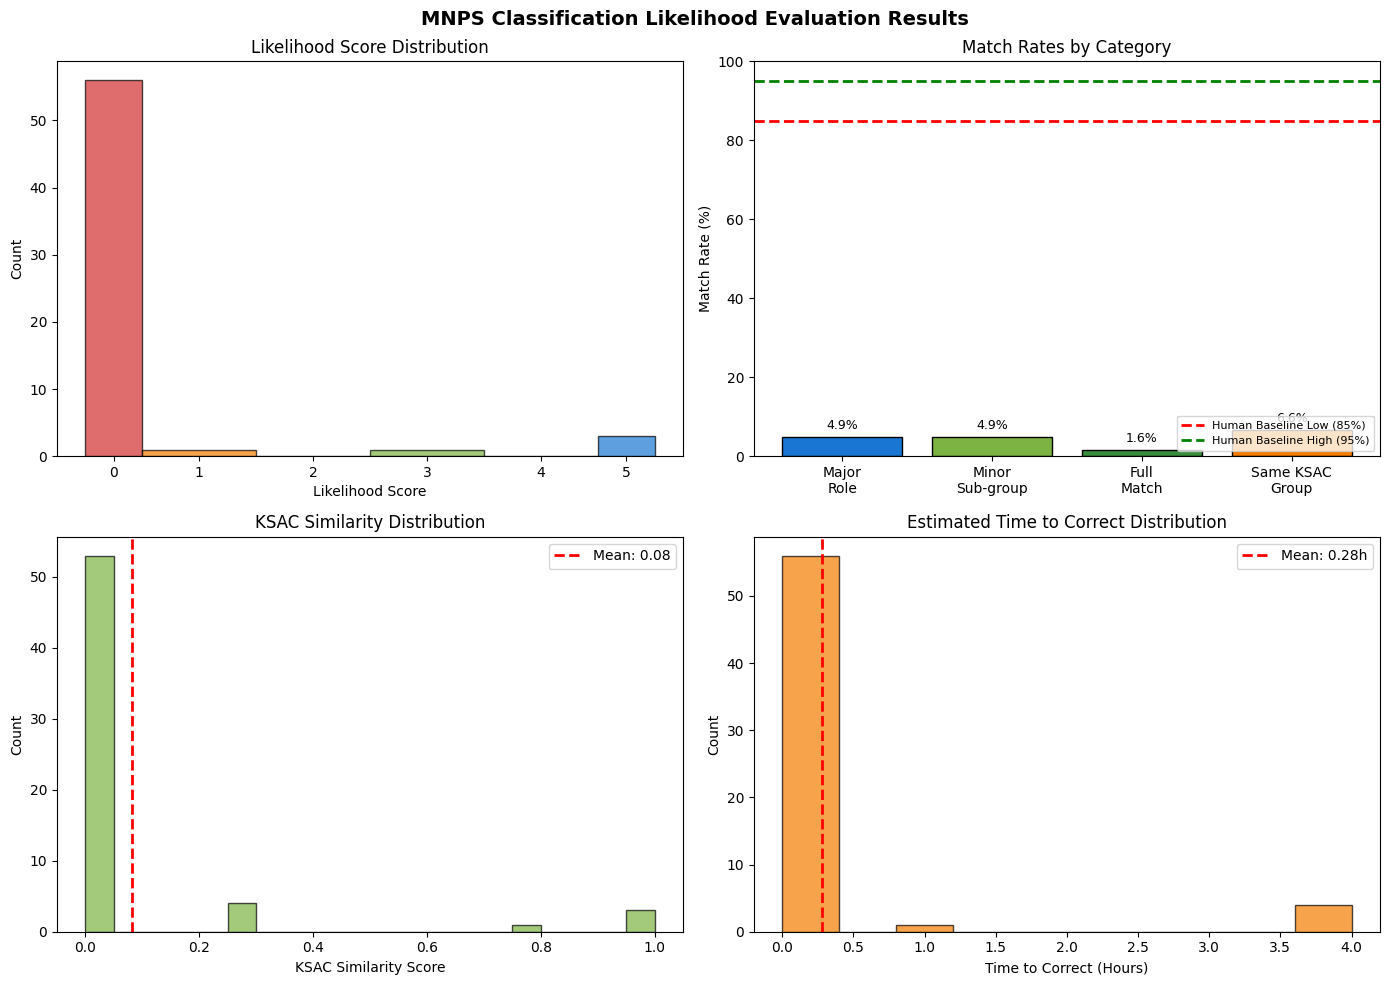

In [18]:
# ==== VISUALIZATIONS ====

import matplotlib.pyplot as plt

if results_df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('MNPS Classification Likelihood Evaluation Results', fontsize=14, fontweight='bold')

    # 1. Likelihood Score Distribution
    ax1 = axes[0, 0]
    bins = [0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.0]
    labels = ['0 (Failure)', '1 (Poor)', '2 (Marginal)', '3 (Acceptable)', '4 (Very Good)', '5 (Excellent)']
    counts, _, patches = ax1.hist(results_df['likelihood_score'], bins=bins, edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Likelihood Score')
    ax1.set_ylabel('Count')
    ax1.set_title('Likelihood Score Distribution')
    ax1.set_xticks([0.25, 1, 2, 3, 4, 4.75])
    ax1.set_xticklabels(['0', '1', '2', '3', '4', '5'])

    # Color bars by score level
    colors = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c', '#1976d2']
    for patch, color in zip(patches, colors):
        patch.set_facecolor(color)

    # 2. Match Rate Comparison
    ax2 = axes[0, 1]
    categories = ['Major\nRole', 'Minor\nSub-group', 'Full\nMatch', 'Same KSAC\nGroup']
    rates = [
        summary['major_match_rate'],
        summary['minor_match_rate'],
        summary['full_match_rate'],
        summary['same_ksac_group_rate']
    ]
    bars = ax2.bar(categories, rates, color=['#1976d2', '#7cb342', '#388e3c', '#f57c00'], edgecolor='black')
    ax2.set_ylabel('Match Rate (%)')
    ax2.set_title('Match Rates by Category')
    ax2.set_ylim(0, 100)

    # Add value labels
    for bar, rate in zip(bars, rates):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{rate:.1f}%', ha='center', fontsize=9)

    # Add human baseline line
    ax2.axhline(y=85, color='red', linestyle='--', linewidth=2, label='Human Baseline Low (85%)')
    ax2.axhline(y=95, color='green', linestyle='--', linewidth=2, label='Human Baseline High (95%)')
    ax2.legend(loc='lower right', fontsize=8)

    # 3. KSAC Similarity Distribution
    ax3 = axes[1, 0]
    ax3.hist(results_df['ksac_similarity'], bins=20, edgecolor='black', alpha=0.7, color='#7cb342')
    ax3.set_xlabel('KSAC Similarity Score')
    ax3.set_ylabel('Count')
    ax3.set_title('KSAC Similarity Distribution')
    ax3.axvline(x=results_df['ksac_similarity'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results_df["ksac_similarity"].mean():.2f}')
    ax3.legend()

    # 4. Time to Correct Distribution
    ax4 = axes[1, 1]
    time_data = results_df['time_to_correct_hours']
    ax4.hist(time_data, bins=10, edgecolor='black', alpha=0.7, color='#f57c00')
    ax4.set_xlabel('Time to Correct (Hours)')
    ax4.set_ylabel('Count')
    ax4.set_title('Estimated Time to Correct Distribution')
    ax4.axvline(x=time_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {time_data.mean():.2f}h')
    ax4.legend()

    plt.tight_layout()

    # Save visualization
    viz_path = OUTPUTS_DIR / 'likelihood_evaluation_charts.png'
    plt.savefig(viz_path, dpi=150, bbox_inches='tight')
    print(f"\n✅ Saved visualization to: {viz_path}")

    plt.show()
else:
    print("No results to visualize")

# ==== 11) Save Results ====

In [21]:
# ==== SAVE ALL RESULTS ====

import numpy as np

def convert_numpy_types(obj):
    """
    Recursively convert NumPy types within a dictionary or list to native Python types.
    """
    if isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(elem) for elem in obj]
    elif isinstance(obj, (np.int_, np.intc, np.intp, np.int8, np.int16, np.int32, np.int64, np.uint8, np.uint16, np.uint32, np.uint64)):
        return int(obj)
    elif isinstance(obj, (np.float16, np.float32, np.float64)):
        return float(obj)
    else:
        return obj


if results_df is not None:
    print("\n" + "="*80)
    print("SAVING RESULTS")
    print("="*80)

    # 1. Save detailed results CSV
    detailed_results_path = OUTPUTS_DIR / 'likelihood_detailed_results.csv'

    # Flatten nested dictionaries for CSV output
    export_df = results_df.copy()

    # Extract salary cost impact fields
    if 'salary_cost_impact' in export_df.columns:
        export_df['salary_absolute_diff'] = export_df['salary_cost_impact'].apply(lambda x: x.get('absolute_diff', None) if isinstance(x, dict) else None)
        export_df['salary_pct_diff'] = export_df['salary_cost_impact'].apply(lambda x: x.get('percentage_diff', None) if isinstance(x, dict) else None)
        export_df['salary_severity'] = export_df['salary_cost_impact'].apply(lambda x: x.get('severity', None) if isinstance(x, dict) else None)
        export_df = export_df.drop('salary_cost_impact', axis=1)

    # Extract score components
    if 'score_components' in export_df.columns:
        for key in ['major_match_component', 'minor_match_component', 'ksac_similarity_component', 'cost_impact_component', 'time_to_correct_component']:
            export_df[key] = export_df['score_components'].apply(lambda x: x.get(key, None) if isinstance(x, dict) else None)
        export_df = export_df.drop('score_components', axis=1)

    export_df.to_csv(detailed_results_path, index=False)
    print(f"✅ Saved detailed results: {detailed_results_path}")

    # 2. Save summary JSON
    summary_path = OUTPUTS_DIR / 'likelihood_summary.json'
    # Convert numpy types in summary to native Python types for JSON serialization
    serializable_summary = convert_numpy_types(summary)
    with open(summary_path, 'w') as f:
        json.dump(serializable_summary, f, indent=2)
    print(f"✅ Saved summary: {summary_path}")

    # 3. Save executive report
    report_path = OUTPUTS_DIR / 'likelihood_executive_report.txt'

    report_content = f"""
MNPS JOB CLASSIFICATION LIKELIHOOD EVALUATION
Executive Report
Generated: {dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*60}

OVERALL ASSESSMENT
{'-'*60}
Total Records Evaluated: {summary['total_records']}
Mean Likelihood Score: {summary['likelihood_score_mean']:.2f} / 5.00
Classifier Performance: {summary['vs_human_assessment']}

ACCURACY METRICS
{'-'*60}
Major Role Match Rate: {summary['major_match_rate']:.1f}%
Minor Sub-group Match Rate: {summary['minor_match_rate']:.1f}%
Full Match Rate: {summary['full_match_rate']:.1f}%

Human Evaluator Baseline: {HUMAN_EVALUATOR_BASELINE['accuracy_range'][0]*100:.0f}% - {HUMAN_EVALUATOR_BASELINE['accuracy_range'][1]*100:.0f}%

KSAC ALIGNMENT
{'-'*60}
Average KSAC Similarity: {summary['ksac_similarity_mean']:.2f}
Same KSAC Group Rate: {summary['same_ksac_group_rate']:.1f}%

ERROR CORRECTION ESTIMATES
{'-'*60}
Total Hours to Correct All Errors: {summary['total_correction_hours']:.1f} hours
Average Hours per Record: {summary['avg_correction_hours']:.2f} hours

LIKELIHOOD SCORE DISTRIBUTION
{'-'*60}
Score 5 (Excellent): {summary['score_5_count']} records ({summary['score_5_count']/summary['total_records']*100:.1f}%)
Score 4 (Very Good): {summary['score_4_count']} records ({summary['score_4_count']/summary['total_records']*100:.1f}%)
Score 3 (Acceptable): {summary['score_3_count']} records ({summary['score_3_count']/summary['total_records']*100:.1f}%)
Score 2 (Marginal): {summary['score_2_count']} records ({summary['score_2_count']/summary['total_records']*100:.1f}%)
Score 1 (Poor): {summary['score_1_count']} records ({summary['score_1_count']/summary['total_records']*100:.1f}%)
Score 0 (Failure): {summary['score_0_count']} records ({summary['score_0_count']/summary['total_records']*100:.1f}%)

INTERPRETATION
{'-'*60}
The Likelihood Score represents how likely the classifier's job classification
would match that of a human evaluator with two years of professional HR
experience in job classification.

Score interpretation:
- 5: Complete match - Identical to human HR professional output
- 4: Strong match - Minor differences, within similar KSAC grouping
- 3: Acceptable - Different but reasonable classification
- 2: Marginal - Noticeable differences with moderate impact
- 1: Poor - Significant misclassification
- 0: Failure - Complete misclassification

{'='*60}
End of Report
"""

    with open(report_path, 'w') as f:
        f.write(report_content)
    print(f"✅ Saved executive report: {report_path}")

    # 4. Copy input files to run folder for reference
    if BATCH_RESULTS_CSV.exists():
        shutil.copy(BATCH_RESULTS_CSV, OUTPUTS_DIR / 'input_Job_Classifications_Batch.csv')
    if SAMPLE_JDS_CSV.exists():
        shutil.copy(SAMPLE_JDS_CSV, OUTPUTS_DIR / 'input_Sample_JDs.csv')

    print(f"\n📁 All results saved to: {OUTPUTS_DIR}")
    print(f"\n🎉 Evaluation Complete!")
else:
    print("No results to save")


SAVING RESULTS
✅ Saved detailed results: /content/drive/My Drive/Likelihood Assessment/Run Results/EVAL_20251208_201231/outputs/likelihood_detailed_results.csv
✅ Saved summary: /content/drive/My Drive/Likelihood Assessment/Run Results/EVAL_20251208_201231/outputs/likelihood_summary.json
✅ Saved executive report: /content/drive/My Drive/Likelihood Assessment/Run Results/EVAL_20251208_201231/outputs/likelihood_executive_report.txt

📁 All results saved to: /content/drive/My Drive/Likelihood Assessment/Run Results/EVAL_20251208_201231/outputs

🎉 Evaluation Complete!


# ==== 12) Quick Test with Sample Data ====

In [22]:
# ==== QUICK TEST ====
# Use this cell to test the likelihood calculation with sample data

print("\n" + "="*80)
print("QUICK TEST: Sample Likelihood Calculations")
print("="*80)

# Test cases
test_cases = [
    {'assigned': 'Manager', 'expected': 'Manager', 'a_minor': 'II', 'e_minor': 'II', 'desc': 'Perfect match'},
    {'assigned': 'Manager', 'expected': 'Manager', 'a_minor': 'II', 'e_minor': 'III', 'desc': 'Same role, different minor'},
    {'assigned': 'Manager', 'expected': 'Coordinator', 'a_minor': 'II', 'e_minor': 'II', 'desc': 'Different role (similar group)'},
    {'assigned': 'Teacher', 'expected': 'Analyst', 'a_minor': 'I', 'e_minor': 'II', 'desc': 'Very different roles'},
    {'assigned': 'Coach', 'expected': 'Coordinator', 'a_minor': 'II', 'e_minor': 'II', 'desc': 'Coach vs Coordinator'},
]

for test in test_cases:
    result = calculate_likelihood_score(
        test['assigned'], test['expected'],
        test['a_minor'], test['e_minor'],
        role_to_group, salary_lookup, time_to_correct_lookup, ksacs_df
    )

    print(f"\n{test['desc']}:")
    print(f"  Assigned: {test['assigned']} {test['a_minor']}")
    print(f"  Expected: {test['expected']} {test['e_minor']}")
    print(f"  Likelihood Score: {result['likelihood_score']:.2f}/5.00")
    print(f"  KSAC Similarity: {result['ksac_similarity']:.2f}")
    print(f"  Same KSAC Group: {result['same_ksac_group']}")
    print(f"  Time to Correct: {result['time_to_correct_hours']:.1f} hours")
    print(f"  Interpretation: {result['interpretation']}")


QUICK TEST: Sample Likelihood Calculations

Perfect match:
  Assigned: Manager II
  Expected: Manager II
  Likelihood Score: 5.00/5.00
  KSAC Similarity: 1.00
  Same KSAC Group: True
  Time to Correct: 0.0 hours
  Interpretation: EXCELLENT: Near-perfect match to human evaluator

Same role, different minor:
  Assigned: Manager II
  Expected: Manager III
  Likelihood Score: 4.62/5.00
  KSAC Similarity: 1.00
  Same KSAC Group: True
  Time to Correct: 0.0 hours
  Interpretation: EXCELLENT: Near-perfect match to human evaluator

Different role (similar group):
  Assigned: Manager II
  Expected: Coordinator II
  Likelihood Score: 1.47/5.00
  KSAC Similarity: 0.30
  Same KSAC Group: False
  Time to Correct: 4.0 hours
  Interpretation: POOR: Significant misclassification, high impact

Very different roles:
  Assigned: Teacher I
  Expected: Analyst II
  Likelihood Score: 0.53/5.00
  KSAC Similarity: 0.30
  Same KSAC Group: False
  Time to Correct: 4.0 hours
  Interpretation: FAILURE: Complete 